In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [2]:
!pip install xgboost lightgbm catboost -q
!pip install optuna -q
!pip install tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 21.5 MB/s eta 0:00:00


# 17 — Probability Calibration
### Early Sepsis Detection — Phase 19

Phase 17's calibration curves showed LightGBM (tuned) is systematically
overconfident (predicted probabilities higher than the true fraction of
positives) — a known side-effect of class-weighting. This notebook tests
Platt scaling (sigmoid) and isotonic regression to correct this, fit on
the validation set (never seen during training/tuning).

**Important consequence handled explicitly:** calibration changes the
probability SCALE. Phase 18's threshold of 0.4 was chosen on the RAW
(uncalibrated) probabilities — it does not automatically transfer to the
calibrated scale. This notebook re-derives the operating threshold in the
new, calibrated probability space using the SAME selection rule as Phase 18
(max F1 among thresholds with recall >= 0.50), rather than reusing 0.4
literally.


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

from src import config
from src import evaluate as ev

# scikit-learn >=1.6 removed `cv='prefit'` in favor of wrapping the fitted
# model with FrozenEstimator; this handles both API generations so the
# notebook runs regardless of which scikit-learn version Colab has installed.
try:
    from sklearn.frozen import FrozenEstimator
    _SKLEARN_NEW_API = True
except ImportError:
    _SKLEARN_NEW_API = False


def make_prefit_calibrator(fitted_model, method):
    """Build a CalibratedClassifierCV around an ALREADY-FITTED model, compatible
    with both old (cv='prefit') and new (FrozenEstimator) scikit-learn APIs."""
    if _SKLEARN_NEW_API:
        return CalibratedClassifierCV(FrozenEstimator(fitted_model), method=method)
    else:
        return CalibratedClassifierCV(fitted_model, method=method, cv="prefit")


npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
X_val, y_val = npz["X_val"], npz["y_val"]
X_test, y_test = npz["X_test"], npz["y_test"]

model = joblib.load(config.MODELS_DIR / "lightgbm_tuned.pkl")
raw_val_prob = model.predict_proba(X_val)[:, 1]
raw_test_prob = model.predict_proba(X_test)[:, 1]

print(f"Uncalibrated Brier score (val):  {brier_score_loss(y_val, raw_val_prob):.4f}")
print(f"Uncalibrated Brier score (test): {brier_score_loss(y_test, raw_test_prob):.4f}")


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Uncalibrated Brier score (val):  0.1269
Uncalibrated Brier score (test): 0.1246


## 1. Fit both calibration methods on the validation set

`cv='prefit'` tells scikit-learn the base model is already trained — only
the calibration mapping itself is fit here, using validation data.


In [4]:
platt_calibrator = make_prefit_calibrator(model, method="sigmoid")
platt_calibrator.fit(X_val, y_val)

isotonic_calibrator = make_prefit_calibrator(model, method="isotonic")
isotonic_calibrator.fit(X_val, y_val)

platt_val_prob = platt_calibrator.predict_proba(X_val)[:, 1]
isotonic_val_prob = isotonic_calibrator.predict_proba(X_val)[:, 1]

print("Both calibrators fit on validation data.")


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Both calibrators fit on validation data.


## 2. Compare calibration curves and Brier scores (validation set)

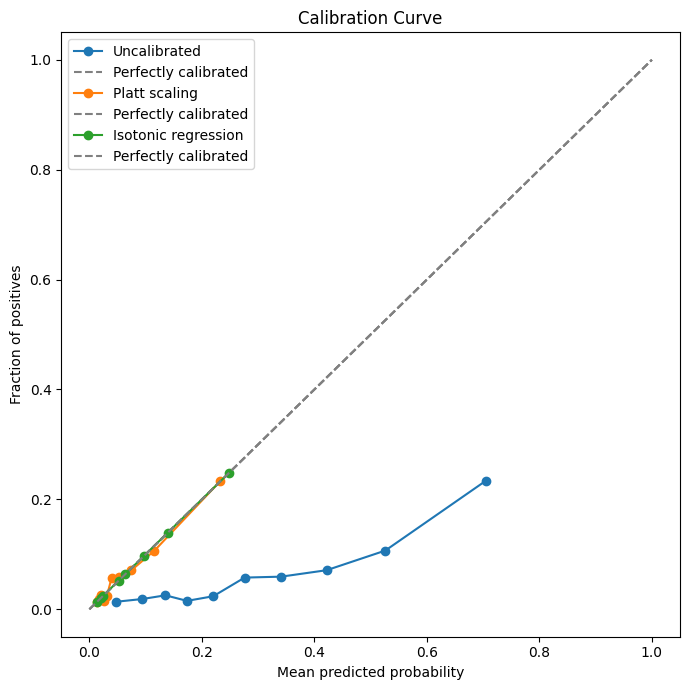

Brier score - Uncalibrated: 0.1269
Brier score - Platt:        0.0537
Brier score - Isotonic:     0.0527


In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ev.plot_calibration_curve(y_val, raw_val_prob, model_name="Uncalibrated", ax=ax)
ev.plot_calibration_curve(y_val, platt_val_prob, model_name="Platt scaling", ax=ax)
ev.plot_calibration_curve(y_val, isotonic_val_prob, model_name="Isotonic regression", ax=ax)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "17_calibration_comparison.png", dpi=150)
plt.show()

print(f"Brier score - Uncalibrated: {brier_score_loss(y_val, raw_val_prob):.4f}")
print(f"Brier score - Platt:        {brier_score_loss(y_val, platt_val_prob):.4f}")
print(f"Brier score - Isotonic:     {brier_score_loss(y_val, isotonic_val_prob):.4f}")


## 3. Confirm ranking metrics (ROC-AUC, PR-AUC) are preserved

Both calibration methods are monotonic (or near-monotonic) transforms of
the raw probability — they should NOT change which patients rank above
others, so ROC-AUC/PR-AUC should stay the same or very close.


In [6]:
for name, prob in [("Uncalibrated", raw_val_prob), ("Platt", platt_val_prob), ("Isotonic", isotonic_val_prob)]:
    m = ev.compute_metrics(y_val, prob, threshold=0.5)
    print(f"{name}: ROC-AUC={m['roc_auc']:.4f}, PR-AUC={m['pr_auc']:.4f}")


Uncalibrated: ROC-AUC=0.7610, PR-AUC=0.2397
Platt: ROC-AUC=0.7610, PR-AUC=0.2397
Isotonic: ROC-AUC=0.7664, PR-AUC=0.2307


## 4. Choose the best calibration method (lowest validation Brier score)

In [7]:
brier_scores = {
    "uncalibrated": brier_score_loss(y_val, raw_val_prob),
    "platt": brier_score_loss(y_val, platt_val_prob),
    "isotonic": brier_score_loss(y_val, isotonic_val_prob),
}
best_method = min(brier_scores, key=brier_scores.get)
print(f"Best calibration method (lowest val Brier score): {best_method}")
print(brier_scores)

if best_method == "platt":
    final_calibrator = platt_calibrator
    final_val_prob = platt_val_prob
elif best_method == "isotonic":
    final_calibrator = isotonic_calibrator
    final_val_prob = isotonic_val_prob
else:
    final_calibrator = None
    final_val_prob = raw_val_prob
    print("Calibration did NOT improve on the raw probabilities — keeping the uncalibrated model.")


Best calibration method (lowest val Brier score): isotonic
{'uncalibrated': np.float64(0.1268663578509498), 'platt': np.float64(0.05371060624508858), 'isotonic': np.float64(0.052697880385993885)}


## 5. Re-derive the operating threshold in the (possibly new) probability scale

Uses the EXACT SAME selection rule as Phase 18 — max F1 among thresholds
with recall >= 0.50 — but searched on a finer grid since calibration can
shift where the useful range of thresholds sits.


In [8]:
fine_grid = np.arange(0.05, 0.95, 0.05)
MIN_RECALL = 0.50

results = []
for t in fine_grid:
    m = ev.compute_metrics(y_val, final_val_prob, threshold=t)
    results.append(m)
results_df = pd.DataFrame(results)

eligible = results_df[results_df["recall_sensitivity"] >= MIN_RECALL]
if len(eligible):
    chosen = eligible.loc[eligible["f1"].idxmax()]
else:
    chosen = results_df.loc[results_df["recall_sensitivity"].idxmax()]

FINAL_THRESHOLD_CALIBRATED = float(chosen["threshold"])
print(f"Re-derived threshold on {best_method} probabilities: {FINAL_THRESHOLD_CALIBRATED:.2f}")
print(f"  precision={chosen['precision']:.4f}, recall={chosen['recall_sensitivity']:.4f}, f1={chosen['f1']:.4f}")


Re-derived threshold on isotonic probabilities: 0.10
  precision=0.1669, recall=0.5718, f1=0.2584


## 6. Final test-set check with the calibrated model + re-derived threshold

In [9]:
if final_calibrator is not None:
    final_test_prob = final_calibrator.predict_proba(X_test)[:, 1]
else:
    final_test_prob = raw_test_prob

final_test_metrics = ev.compute_metrics(y_test, final_test_prob, threshold=FINAL_THRESHOLD_CALIBRATED)
ev.print_metrics(final_test_metrics, model_name=f"LightGBM (tuned, {best_method}), test")
ev.save_model_results(f"LightGBM_tuned_{best_method}_FINAL_TEST", final_test_metrics)

print(f"\nBrier score comparison (test set):")
print(f"  Uncalibrated: {brier_score_loss(y_test, raw_test_prob):.4f}")
print(f"  {best_method.capitalize()}:  {brier_score_loss(y_test, final_test_prob):.4f}")


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM (tuned, isotonic), test (threshold=0.1) ---
  ROC-AUC:            0.7533
  PR-AUC:             0.2232
  Precision:          0.1599
  Recall (Sensitivity): 0.5243
  Specificity:        0.8159
  F1:                 0.2451
  Brier score:        0.0533
  Confusion matrix:   TN=4517 FP=1019 FN=176 TP=194


2026-09-15 08:22:56,795 | INFO | src.evaluate | Saved/updated results for 'LightGBM_tuned_isotonic_FINAL_TEST' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'LightGBM_tuned_isotonic_FINAL_TEST' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv



Brier score comparison (test set):
  Uncalibrated: 0.1246
  Isotonic:  0.0533


## 7. Save the calibrator and updated threshold decision

In [10]:
if final_calibrator is not None:
    joblib.dump(final_calibrator, config.MODELS_DIR / "lightgbm_tuned_calibrated.pkl")

import json
calibration_decision = {
    "calibration_method": best_method,
    "brier_scores": brier_scores,
    "final_threshold": FINAL_THRESHOLD_CALIBRATED,
    "final_test_metrics": final_test_metrics,
}
with open(config.TABLES_DIR / "17_calibration_decision.json", "w") as f:
    json.dump(calibration_decision, f, indent=2, default=str)

print("Saved calibrator and calibration decision.")


Saved calibrator and calibration decision.


---
### What to send back to Claude after running this notebook

- Section 2's Brier scores for all 3 approaches
- Section 3's confirmation that ROC-AUC/PR-AUC stayed stable
- Section 4's chosen best method
- Section 6's final test-set metrics with the re-derived threshold

With that, **Phase 19 is complete**, and we move to **Phase 20 (SHAP
Explainability)** — using SHAP on LightGBM (tuned) to explain both global
feature importance and individual patient predictions.
